In [ ]:
import numpy as np
from scipy.stats import entropy
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime, timedelta

[*********************100%%**********************]  1 of 1 completed


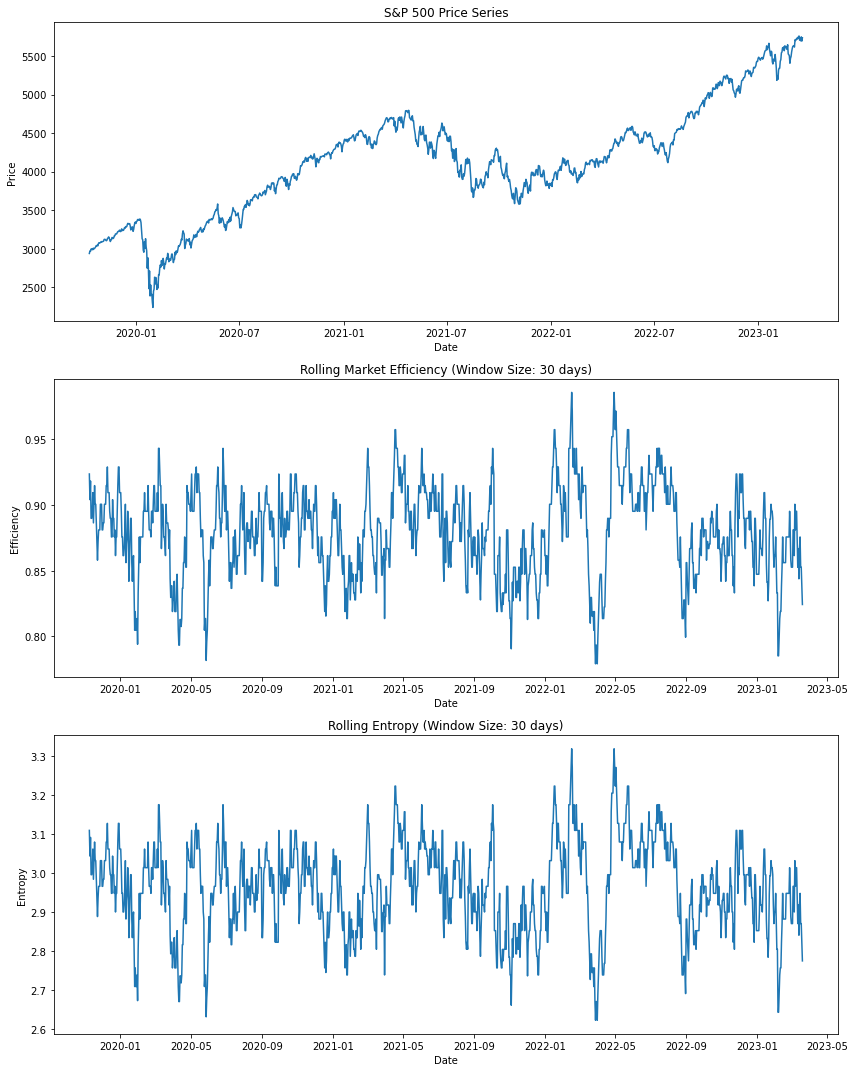


Results:
Overall Market Efficiency: 0.3319
Overall Entropy: 2.3680


In [1]:
def calculate_returns(prices):
    return np.diff(np.log(prices))

def calculate_entropy(returns, bins=50):
    hist, _ = np.histogram(returns, bins=bins, density=True)
    return entropy(hist)

def get_sp500_data(start_date, end_date):
    ticker = "^GSPC"  # S&P 500 ticker symbol
    data = yf.download(ticker, start=start_date, end=end_date)
    return data['Adj Close'].values

def analyze_market_efficiency(prices):
    returns = calculate_returns(prices)
    entropy_value = calculate_entropy(returns)
    
    # Normalize entropy to a 0-1 scale for easier interpretation
    max_entropy = np.log(len(returns))
    normalized_entropy = entropy_value / max_entropy
    
    efficiency = normalized_entropy
    return efficiency, entropy_value

def plot_results(dates, prices, window_size):
    fig, axs = plt.subplots(3, 1, figsize=(12, 15))
    
    # Plot price series
    axs[0].plot(dates, prices)
    axs[0].set_title('S&P 500 Price Series')
    axs[0].set_xlabel('Date')
    axs[0].set_ylabel('Price')
    
    # Calculate rolling efficiency
    efficiencies = []
    entropies = []
    
    for i in range(len(prices) - window_size + 1):
        window_prices = prices[i:i+window_size]
        eff, ent = analyze_market_efficiency(window_prices)
        efficiencies.append(eff)
        entropies.append(ent)
    
    # Plot rolling efficiency
    axs[1].plot(dates[window_size-1:], efficiencies)
    axs[1].set_title(f'Rolling Market Efficiency (Window Size: {window_size} days)')
    axs[1].set_xlabel('Date')
    axs[1].set_ylabel('Efficiency')
    
    # Plot rolling entropy
    axs[2].plot(dates[window_size-1:], entropies)
    axs[2].set_title(f'Rolling Entropy (Window Size: {window_size} days)')
    axs[2].set_xlabel('Date')
    axs[2].set_ylabel('Entropy')
    
    plt.tight_layout()
    plt.show()

def main():
    # Set date range for data
    end_date = datetime.now()
    start_date = end_date - timedelta(days=5*365)  # 5 years of data
    
    # Get S&P 500 data
    prices = get_sp500_data(start_date, end_date)
    dates = np.array([start_date + timedelta(days=i) for i in range(len(prices))])
    
    # Set window size for rolling analysis (e.g., 30 days)
    window_size = 30
    
    plot_results(dates, prices, window_size)
    
    # Calculate overall market efficiency
    overall_efficiency, overall_entropy = analyze_market_efficiency(prices)
    
    print("\nResults:")
    print(f"Overall Market Efficiency: {overall_efficiency:.4f}")
    print(f"Overall Entropy: {overall_entropy:.4f}")

if __name__ == "__main__":
    main()